# HireGenius — NLP Module
Pipeline complet : preprocessing, embeddings SBERT, NER, matching hybride CV/JD, feedback Gemini, evaluation MLflow.

## Section 1 — Setup & Data Loading

In [1]:
# Installation unique — lancer une seule fois
%pip install -q spacy sentence-transformers transformers pdfplumber \
    langchain-community langchain-huggingface chromadb mlflow \
    plotly seaborn scikit-learn pandas numpy tqdm google-generativeai
!python -m spacy download en_core_web_trf -q

Note: you may need to restart the kernel to use updated packages.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_trf')


In [22]:
%pip install google-genai

   ---------------------------------------- 0.0/783.6 kB ? eta -:--:--
   -------------------------- ------------- 524.3/783.6 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 783.6/783.6 kB 6.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install --upgrade nbformat

Note: you may need to restart the kernel to use updated packages.


In [23]:
import os
import re
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import torch
import mlflow
import spacy
import google.genai as genai
from sentence_transformers import SentenceTransformer, util
from tqdm import tqdm
from collections import Counter

print("Imports OK")

Imports OK


In [2]:
df_resumes = pd.read_csv('../Resume/Resume.csv')
print(f"Resumes charges : {len(df_resumes)}")
print(f"Colonnes : {df_resumes.columns.tolist()}")
print(f"Categories : {df_resumes['Category'].nunique()} categories")

df_jobs = pd.read_csv('../postings.csv', nrows=5000)
df_jobs['description'] = df_jobs['description'].fillna('')
print(f"\nJob postings charges : {len(df_jobs)}")
print(f"Colonnes jobs : {df_jobs.columns.tolist()}")

Resumes charges : 2484
Colonnes : ['ID', 'Resume_str', 'Resume_html', 'Category']
Categories : 24 categories

Job postings charges : 5000
Colonnes jobs : ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


In [3]:
# Distribution des categories
cat_counts = df_resumes['Category'].value_counts().reset_index()
cat_counts.columns = ['Category', 'Count']

fig = px.bar(
    cat_counts,
    x='Count', y='Category',
    orientation='h',
    title='Distribution des CVs par categorie',
    color='Count',
    color_continuous_scale='Blues'
)
fig.update_layout(height=600, showlegend=False)
fig.show()

print(f"\nTotal CVs : {len(df_resumes)}")
print(cat_counts.to_string(index=False))


Total CVs : 2484
              Category  Count
INFORMATION-TECHNOLOGY    120
  BUSINESS-DEVELOPMENT    120
              ADVOCATE    118
                  CHEF    118
           ENGINEERING    118
            ACCOUNTANT    118
               FINANCE    118
               FITNESS    117
              AVIATION    117
                 SALES    116
               BANKING    115
            HEALTHCARE    115
            CONSULTANT    115
          CONSTRUCTION    112
      PUBLIC-RELATIONS    111
                    HR    110
              DESIGNER    107
                  ARTS    103
               TEACHER    102
               APPAREL     97
         DIGITAL-MEDIA     96
           AGRICULTURE     63
            AUTOMOBILE     36
                   BPO     22


## Section 2 — Preprocessing & Cleaning

In [4]:
nlp = spacy.load('en_core_web_trf')
print("spaCy model charge : en_core_web_trf")

spaCy model charge : en_core_web_trf


In [5]:
def clean_resume(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^\w\s\.\,\-\/]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.lower().strip()
    return text


SECTION_PATTERNS = {
    'skills':     r'(skills?|competenc|technical|technologies|proficienc)',
    'experience': r'(experience|work history|employment|career|position)',
    'education':  r'(education|academic|degree|university|diploma|certif)',
    'summary':    r'(summary|profile|objective|about|overview)'
}

def segment_resume(text: str) -> dict:
    sections = {k: '' for k in SECTION_PATTERNS}
    lines = text.split('\n')
    current = 'summary'
    for line in lines:
        line_lower = line.lower().strip()
        for section, pattern in SECTION_PATTERNS.items():
            if re.search(pattern, line_lower) and len(line_lower) < 50:
                current = section
                break
        sections[current] += ' ' + line
    return {k: v.strip() for k, v in sections.items()}


print("Nettoyage des resumes...")
df_resumes['clean_text'] = df_resumes['Resume_str'].apply(clean_resume)
df_resumes['sections'] = df_resumes['Resume_str'].apply(segment_resume)

print("Nettoyage des job descriptions...")
df_jobs['clean_description'] = df_jobs['description'].apply(clean_resume)

print(f"Preprocessing termine — {len(df_resumes)} resumes, {len(df_jobs)} jobs")
df_resumes[['ID', 'Category', 'clean_text']].head(3)

Nettoyage des resumes...
Nettoyage des job descriptions...
Preprocessing termine — 2484 resumes, 5000 jobs


,ID,Category,clean_text
0,16852973,HR,hr administrator/marketing associate hr admini...
1,22323967,HR,"hr specialist, us hr operations summary versat..."
2,33176873,HR,hr director summary over 20 years experience i...


Longueur moyenne des CVs : 5891 caracteres
Longueur moyenne des JDs : 3508 caracteres


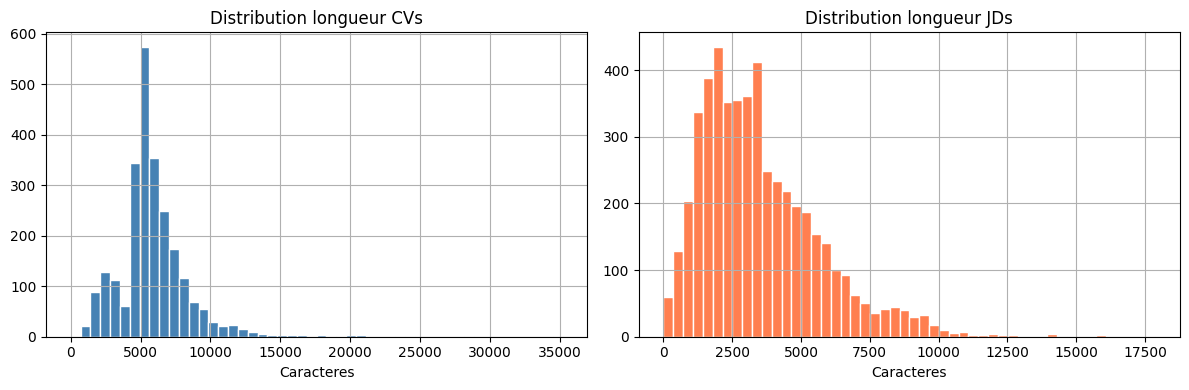

In [6]:
# Statistiques sur la longueur des textes
df_resumes['text_length'] = df_resumes['clean_text'].str.len()
df_jobs['text_length'] = df_jobs['clean_description'].str.len()

print("Longueur moyenne des CVs :", round(df_resumes['text_length'].mean()), "caracteres")
print("Longueur moyenne des JDs :", round(df_jobs['text_length'].mean()), "caracteres")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_resumes['text_length'].hist(ax=axes[0], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution longueur CVs')
axes[0].set_xlabel('Caracteres')
df_jobs['text_length'].hist(ax=axes[1], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution longueur JDs')
axes[1].set_xlabel('Caracteres')
plt.tight_layout()
plt.show()

## Section 3 — Feature Engineering & Embeddings

In [7]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
os.makedirs('../data/processed', exist_ok=True)

print("Encodage des CVs...")
cv_embeddings = sbert_model.encode(
    df_resumes['clean_text'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save('../data/processed/cv_embeddings.npy', cv_embeddings)
print(f"cv_embeddings shape : {cv_embeddings.shape}")

print("\nEncodage des job descriptions...")
jd_embeddings = sbert_model.encode(
    df_jobs['clean_description'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
np.save('../data/processed/jd_embeddings.npy', jd_embeddings)
print(f"jd_embeddings shape : {jd_embeddings.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4122.74it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encodage des CVs...


Batches: 100%|██████████| 78/78 [02:42<00:00,  2.08s/it]


cv_embeddings shape : (2484, 384)

Encodage des job descriptions...


Batches: 100%|██████████| 157/157 [05:49<00:00,  2.23s/it]

jd_embeddings shape : (5000, 384)


In [8]:
# Visualisation UMAP des embeddings CVs (sous-echantillon pour la rapidite)
try:
    import umap
except ImportError:
    %pip install -q umap-learn
    import umap

sample_idx = np.random.choice(len(cv_embeddings), size=500, replace=False)
sample_emb = cv_embeddings[sample_idx]
sample_cats = df_resumes['Category'].iloc[sample_idx].values

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
coords = reducer.fit_transform(sample_emb)

fig = px.scatter(
    x=coords[:, 0], y=coords[:, 1],
    color=sample_cats,
    title='UMAP des embeddings CVs par categorie (500 echantillons)',
    labels={'x': 'UMAP-1', 'y': 'UMAP-2', 'color': 'Categorie'},
    opacity=0.7,
    width=900, height=600
)
fig.show()

Note: you may need to restart the kernel to use updated packages.


c:\Users\chlih\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## Section 4 — Named Entity Recognition (NER)

In [9]:
# Dictionnaire etendu de skills — couvre les 24 categories du dataset
TECH_SKILLS = {
    'programming':  ['python', 'java', 'javascript', 'typescript', 'sql', 'r', 'scala',
                     'c++', 'c#', 'go', 'ruby', 'php', 'swift', 'kotlin', 'matlab'],
    'ml_ai':        ['machine learning', 'deep learning', 'nlp', 'computer vision',
                     'tensorflow', 'pytorch', 'scikit-learn', 'transformers', 'bert',
                     'gpt', 'llm', 'rag', 'reinforcement learning', 'xgboost', 'yolov8'],
    'data':         ['pandas', 'numpy', 'spark', 'hadoop', 'kafka', 'airflow',
                     'tableau', 'power bi', 'excel', 'looker', 'dbt', 'etl'],
    'devops':       ['docker', 'kubernetes', 'ci/cd', 'jenkins', 'terraform',
                     'aws', 'azure', 'gcp', 'linux', 'git', 'ansible'],
    'web':          ['react', 'fastapi', 'django', 'flask', 'html', 'css',
                     'rest api', 'graphql', 'node.js', 'vue', 'angular'],
    'database':     ['postgresql', 'mysql', 'mongodb', 'redis', 'cassandra',
                     'neo4j', 'elasticsearch', 'sqlite', 'oracle'],
    'finance':      ['accounting', 'auditing', 'financial analysis', 'quickbooks',
                     'sap', 'budgeting', 'forecasting', 'tax', 'gaap', 'ifrs'],
    'healthcare':   ['clinical', 'patient care', 'ehr', 'hipaa', 'nursing',
                     'diagnosis', 'pharmacology', 'medical coding', 'icd'],
    'hr':           ['recruitment', 'onboarding', 'performance management', 'hris',
                     'payroll', 'talent acquisition', 'succession planning'],
    'sales':        ['crm', 'salesforce', 'lead generation', 'negotiation',
                     'account management', 'cold calling', 'b2b', 'b2c'],
    'design':       ['figma', 'adobe xd', 'sketch', 'photoshop', 'illustrator',
                     'indesign', 'ui/ux', 'wireframing', 'prototyping'],
    'soft_skills':  ['communication', 'leadership', 'teamwork', 'problem solving',
                     'project management', 'agile', 'scrum', 'time management']
}

def extract_skills(text: str) -> list:
    if not isinstance(text, str):
        return []
    text_lower = text.lower()
    found = []
    for category, skills in TECH_SKILLS.items():
        for skill in skills:
            if skill in text_lower:
                found.append(skill)
    return list(set(found))


def extract_skills_by_category(text: str) -> dict:
    if not isinstance(text, str):
        return {}
    text_lower = text.lower()
    result = {}
    for category, skills in TECH_SKILLS.items():
        found = [s for s in skills if s in text_lower]
        if found:
            result[category] = found
    return result


print("Skills extraits pour le premier CV :")
sample = df_resumes['clean_text'].iloc[0]
print(extract_skills_by_category(sample))

Skills extraits pour le premier CV :
{'programming': ['r', 'go', 'swift'], 'devops': ['aws'], 'finance': ['accounting', 'budgeting'], 'healthcare': ['icd'], 'hr': ['payroll'], 'soft_skills': ['leadership', 'time management']}


In [10]:
def extract_entities_spacy(text: str) -> dict:
    """
    Extrait les entites nommees avec spaCy : organisations, dates, lieux.
    Limite le texte a 5000 caracteres pour la performance.
    """
    doc = nlp(text[:5000])
    entities = {'ORG': [], 'DATE': [], 'GPE': [], 'PERSON': []}
    for ent in doc.ents:
        if ent.label_ in entities:
            entities[ent.label_].append(ent.text)
    # Deduplication
    return {k: list(set(v)) for k, v in entities.items()}


SAMPLE_SIZE = 100
print(f"Extraction NER sur {SAMPLE_SIZE} CVs...")

ner_results = []
for text in tqdm(df_resumes['clean_text'].head(SAMPLE_SIZE).tolist()):
    ner_results.append(extract_entities_spacy(text))

df_resumes.loc[:SAMPLE_SIZE-1, 'entities'] = [str(r) for r in ner_results]

# Extraction des skills sur tous les CVs
print("Extraction des skills sur tous les CVs...")
df_resumes['skills'] = df_resumes['clean_text'].apply(extract_skills)
df_resumes['skills_by_category'] = df_resumes['clean_text'].apply(extract_skills_by_category)

print("Done.")
df_resumes[['ID', 'Category', 'skills']].head(5)

Extraction NER sur 100 CVs...


100%|██████████| 100/100 [03:54<00:00,  2.35s/it]


Extraction des skills sur tous les CVs...
Done.


,ID,Category,skills
0,16852973,HR,"[aws, payroll, time management, r, accounting,..."
1,22323967,HR,"[photoshop, illustrator, recruitment, r, git, ..."
2,33176873,HR,"[payroll, project management, hris, excel, rec..."
3,27018550,HR,"[r, excel, communication, payroll]"
4,17812897,HR,"[aws, payroll, problem solving, hris, excel, r..."


In [11]:
# Top skills globaux
all_skills = [skill for skills_list in df_resumes['skills'] for skill in skills_list]
skill_counts = Counter(all_skills).most_common(25)

skills_df = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])
fig = px.bar(
    skills_df,
    x='Count', y='Skill',
    orientation='h',
    title='Top 25 skills dans les CVs',
    color='Count',
    color_continuous_scale='Teal'
)
fig.update_layout(height=700, showlegend=False)
fig.show()

# Moyenne de skills par categorie
df_resumes['skills_count'] = df_resumes['skills'].apply(len)
avg_skills = df_resumes.groupby('Category')['skills_count'].mean().sort_values(ascending=False)
print("\nNombre moyen de skills par categorie :")
print(avg_skills.round(2).to_string())


Nombre moyen de skills par categorie :
Category
HR                        9.64
FINANCE                   9.40
ACCOUNTANT                8.99
DIGITAL-MEDIA             8.92
CONSULTANT                8.79
INFORMATION-TECHNOLOGY    8.76
HEALTHCARE                8.39
BPO                       8.36
BUSINESS-DEVELOPMENT      8.28
BANKING                   7.97
PUBLIC-RELATIONS          7.81
ADVOCATE                  7.28
AUTOMOBILE                7.06
DESIGNER                  7.04
ENGINEERING               6.96
AGRICULTURE               6.87
CONSTRUCTION              6.54
APPAREL                   6.47
SALES                     6.34
ARTS                      6.32
FITNESS                   6.32
AVIATION                  5.86
CHEF                      5.68
TEACHER                   5.49


## Section 5 — Matching CV / Job Description

In [12]:
# Extraction des skills dans les job descriptions
print("Extraction skills dans les JDs...")
df_jobs['skills'] = df_jobs['clean_description'].apply(extract_skills)
print(f"JDs avec au moins 1 skill identifie : {(df_jobs['skills'].apply(len) > 0).sum()}")

Extraction skills dans les JDs...
JDs avec au moins 1 skill identifie : 4997


In [13]:
def hybrid_score(
    cv_text: str,
    jd_text: str,
    cv_emb,
    jd_emb,
    w_semantic: float = 0.6,
    w_keyword: float = 0.4
) -> dict:
    """
    Score hybride : 60% similarite semantique SBERT + 40% keyword overlap.
    Retourne un dict avec le score final et les details.
    """
    semantic = float(util.cos_sim(cv_emb, jd_emb))

    cv_skills = set(extract_skills(cv_text))
    jd_skills = set(extract_skills(jd_text))
    keyword = len(cv_skills & jd_skills) / len(jd_skills) if jd_skills else 0.0

    final = w_semantic * semantic + w_keyword * keyword

    return {
        'score':          round(final * 100, 2),
        'semantic_score': round(semantic * 100, 2),
        'keyword_score':  round(keyword * 100, 2),
        'matched_skills': list(cv_skills & jd_skills),
        'missing_skills': list(jd_skills - cv_skills)
    }


def rank_candidates(
    jd_index: int,
    df_resumes: pd.DataFrame,
    cv_embeddings: np.ndarray,
    jd_embeddings: np.ndarray,
    top_k: int = 10
) -> pd.DataFrame:
    """
    Classe les candidats par score hybride pour un poste donne.
    jd_index : indice de la ligne dans df_jobs.
    """
    jd_text = df_jobs['clean_description'].iloc[jd_index]
    jd_emb  = jd_embeddings[jd_index]

    records = []
    for i, row in df_resumes.iterrows():
        result = hybrid_score(
            row['clean_text'], jd_text,
            cv_embeddings[i], jd_emb
        )
        records.append({
            'resume_id':       row['ID'],
            'category':        row['Category'],
            'score':           result['score'],
            'semantic_score':  result['semantic_score'],
            'keyword_score':   result['keyword_score'],
            'matched_skills':  result['matched_skills'],
            'missing_skills':  result['missing_skills']
        })

    ranked = pd.DataFrame(records).sort_values('score', ascending=False)
    return ranked.head(top_k).reset_index(drop=True)


print("Fonctions hybrid_score et rank_candidates definies.")

Fonctions hybrid_score et rank_candidates definies.


In [14]:
# Exemple : classer les candidats pour le premier poste du dataset
JD_INDEX = 0
job_title  = df_jobs['title'].iloc[JD_INDEX] if 'title' in df_jobs.columns else 'Poste N/A'
print(f"Poste : {job_title}")
print(f"Description (extrait) : {df_jobs['clean_description'].iloc[JD_INDEX][:200]}...\n")

ranking = rank_candidates(
    jd_index=JD_INDEX,
    df_resumes=df_resumes,
    cv_embeddings=cv_embeddings,
    jd_embeddings=jd_embeddings,
    top_k=10
)
print("Top 10 candidats :")
display(ranking[['resume_id', 'category', 'score', 'semantic_score', 'keyword_score', 'matched_skills']])

Poste : Marketing Coordinator
Description (extrait) : job descriptiona leading real estate firm in new jersey is seeking an administrative marketing coordinator with some experience in graphic design. you will be working closely with our fun, kind, ambit...

Top 10 candidats :


,resume_id,category,score,semantic_score,keyword_score,matched_skills
0,23719943,APPAREL,73.85,56.42,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
1,15425154,DESIGNER,73.76,56.26,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
2,26676567,DESIGNER,73.30,55.50,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
3,18198627,DESIGNER,73.24,55.40,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
4,28629430,ARTS,72.99,66.09,83.33,"[photoshop, illustrator, r, indesign, go]"
5,20470943,PUBLIC-RELATIONS,71.68,52.80,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
6,21283733,DESIGNER,71.65,52.76,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
7,26167298,CONSULTANT,71.27,52.12,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
8,18900722,DIGITAL-MEDIA,70.62,51.04,100.00,"[photoshop, illustrator, rag, r, indesign, go]"
9,13014900,DESIGNER,70.08,50.14,100.00,"[photoshop, illustrator, rag, r, indesign, go]"


In [15]:
# Visualisation du top 10
fig = px.bar(
    ranking,
    x='score',
    y=ranking.index.astype(str),
    orientation='h',
    color='semantic_score',
    title=f'Top 10 candidats pour : {job_title}',
    labels={
        'score': 'Score hybride (/100)',
        'y': 'Rang',
        'semantic_score': 'Score semantique'
    },
    color_continuous_scale='Blues',
    text='category'
)
fig.update_traces(textposition='inside')
fig.update_layout(height=450, yaxis={'autorange': 'reversed'})
fig.show()

## Section 6 — Feedback LLM avec Google Gemini + RAG (ChromaDB)

In [16]:
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

hf_embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')

# Index des 1000 premieres JDs dans ChromaDB
print("Construction de l index ChromaDB...")
vectorstore = Chroma.from_texts(
    texts=df_jobs['clean_description'].tolist()[:1000],
    embedding=hf_embeddings,
    metadatas=[
        {'job_id': str(df_jobs['job_id'].iloc[i]) if 'job_id' in df_jobs.columns else str(i),
         'title':  str(df_jobs['title'].iloc[i]) if 'title' in df_jobs.columns else ''}
        for i in range(1000)
    ],
    collection_name='job_postings'
)
retriever = vectorstore.as_retriever(search_kwargs={'k': 3})
print("ChromaDB pret.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6602.88it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Construction de l index ChromaDB...
ChromaDB pret.


In [25]:
from google import genai

GEMINI_API_KEY = '' 

try:
    client = genai.Client(api_key=GEMINI_API_KEY)
    
    test_resp = client.models.generate_content(
        model='gemini-2.5-flash',
        contents='Respond with only the word: OK'
    )
    print(f"Gemini connecte. Modele : gemini-2.5-flash — test : {test_resp.text.strip()}")
    GEMINI_AVAILABLE = True
except Exception as e:
    print(f"Erreur connexion Gemini : {e}")
    GEMINI_AVAILABLE = False

Gemini connecte. Modele : gemini-2.5-flash — test : OK


In [38]:
import time
import json
import re
from pydantic import BaseModel, Field

# 1. DEFINE YOUR EXACT DESIRED OUTPUT SCHEMA
class CandidateFeedback(BaseModel):
    overall_score: int = Field(description="Integer score from 0 to 100")
    recommendation: str = Field(description="One of: STRONG_MATCH, GOOD_MATCH, PARTIAL_MATCH, NO_MATCH")
    strengths: list[str] = Field(description="List of 3 candidate strengths")
    gaps: list[str] = Field(description="List of 2 candidate gaps or missing skills")
    feedback_summary: str = Field(description="2-3 sentences of feedback for the candidate")
    interview_questions: list[str] = Field(description="3 tailored interview questions")


def retrieve_similar_jds(cv_text: str, k: int = 3) -> list:
    """Recupere les k offres les plus proches du CV via ChromaDB."""
    docs = retriever.invoke(cv_text[:2000])
    return [d.page_content for d in docs]


def build_feedback_prompt(
    cv_text: str,
    jd_text: str,
    score_details: dict,
    similar_jds: list = None
) -> str:
    rag_context = ''
    if similar_jds:
        rag_context = '\n\n## Offres similaires dans la base (contexte supplementaire)\n'
        for i, jd in enumerate(similar_jds, 1):
            rag_context += f'Offre {i}: {jd[:300]}\n'

    # Note: We removed the manual JSON template because the SDK handles it now!
    return f"""You are a senior HR expert and career coach. Analyze the match between this resume and job description.

## Job Description
{jd_text[:1500]}
{rag_context}
## Candidate Resume
{cv_text[:2000]}

## Pre-computed Analysis
- Overall score: {score_details['score']}/100
- Semantic similarity: {score_details['semantic_score']}/100
- Keyword match: {score_details['keyword_score']}/100
- Matched skills: {', '.join(score_details['matched_skills']) or 'none'}
- Missing skills: {', '.join(score_details['missing_skills']) or 'none'}
"""


def generate_feedback(
    cv_text: str,
    jd_text: str,
    score_details: dict,
    use_rag: bool = True,
    max_retries: int = 3
) -> dict:
    
    if not GEMINI_AVAILABLE:
        return {'error': 'Gemini non disponible'}

    similar_jds = retrieve_similar_jds(cv_text) if use_rag else None
    prompt = build_feedback_prompt(cv_text, jd_text, score_details, similar_jds)
    
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model='gemini-2.5-flash',
                contents=prompt,
                config=genai.types.GenerateContentConfig(
                    temperature=0.2,
                    max_output_tokens=8192,
                    response_mime_type="application/json",
                    # ENFORCE THE SCHEMA HERE
                    response_schema=CandidateFeedback 
                )
            )
            
            # The SDK guarantees the text is a valid JSON string matching your schema
            return json.loads(response.text)
            
        except json.JSONDecodeError as e:
            print(f"Erreur de formatage JSON (tentative {attempt+1}/{max_retries})...")
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            return {'error': f"Invalid JSON format: {e}", 'raw_response': response.text}
            
        except Exception as e:
            error_msg = str(e)
            if '503' in error_msg and attempt < max_retries - 1:
                wait_time = (attempt + 1) * 5
                print(f"Serveur occupe (503). Nouvelle tentative dans {wait_time} secondes...")
                time.sleep(wait_time)
                continue
            
            return {'error': error_msg}

In [39]:
# Generation du feedback pour le meilleur candidat du ranking
best_candidate_idx = ranking.index[0]
best_cv_text = df_resumes['clean_text'].iloc[
    df_resumes.index[df_resumes['ID'] == ranking.loc[0, 'resume_id']].tolist()[0]
    if len(df_resumes.index[df_resumes['ID'] == ranking.loc[0, 'resume_id']].tolist()) > 0
    else 0
]
best_score = {
    'score':          ranking.loc[0, 'score'],
    'semantic_score': ranking.loc[0, 'semantic_score'],
    'keyword_score':  ranking.loc[0, 'keyword_score'],
    'matched_skills': ranking.loc[0, 'matched_skills'],
    'missing_skills': ranking.loc[0, 'missing_skills']
}
jd_text_example = df_jobs['clean_description'].iloc[JD_INDEX]

print(f"Generation du feedback pour le candidat rank 1 (score: {best_score['score']}/100)...")
feedback = generate_feedback(best_cv_text, jd_text_example, best_score, use_rag=True)
print(json.dumps(feedback, indent=2, ensure_ascii=False))

Generation du feedback pour le candidat rank 1 (score: 73.85/100)...
{
  "overall_score": 74,
  "recommendation": "GOOD_MATCH",
  "strengths": [
    "Exceptional Graphic Design Proficiency: Highly skilled in Adobe Creative Suite (Illustrator, Photoshop, InDesign) and Microsoft Office, directly matching core technical requirements.",
    "Extensive Product Development & Branding Experience: Proven ability to manage brand strategy, design graphics, and execute product details, which translates well to marketing materials.",
    "Client Collaboration & Cross-Functional Work: Experience working directly with clients and cross-functionally, demonstrating strong interpersonal and project management skills."
  ],
  "gaps": [
    "Lack of Direct Real Estate Industry Experience: The resume is heavily focused on apparel and product development, without explicit experience in a real estate marketing or administrative context.",
    "Limited Explicit Administrative Coordination Experience: While t

## Section 7 — Evaluation & MLflow Tracking

In [40]:
def ndcg_at_k(ranked_categories: list, relevant_category: str, k: int = 5) -> float:
    """
    NDCG@k : mesure la qualite du ranking.
    Considere comme pertinent tout candidat de la meme categorie que le poste.
    """
    dcg = sum(
        1.0 / np.log2(i + 2)
        for i, cat in enumerate(ranked_categories[:k])
        if cat == relevant_category
    )
    n_relevant = sum(1 for c in ranked_categories if c == relevant_category)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(n_relevant, k)))
    return round(dcg / idcg, 4) if idcg > 0 else 0.0


def mean_reciprocal_rank(ranked_categories: list, relevant_category: str) -> float:
    """MRR : position du premier candidat pertinent dans le ranking."""
    for i, cat in enumerate(ranked_categories):
        if cat == relevant_category:
            return round(1.0 / (i + 1), 4)
    return 0.0


def precision_at_k(ranked_categories: list, relevant_category: str, k: int = 5) -> float:
    """Precision@k : proportion de candidats pertinents dans le top k."""
    top_k = ranked_categories[:k]
    relevant = sum(1 for c in top_k if c == relevant_category)
    return round(relevant / k, 4)


print("Fonctions de metriques definies.")

Fonctions de metriques definies.


In [ ]:
# Evaluation sur plusieurs postes
N_EVAL_JOBS = 100 
print(f"Evaluation sur {N_EVAL_JOBS} postes...")

ndcg_scores, mrr_scores, prec_scores = [], [], []

# NOUVEAU : Dictionnaire pour lier les mots-clés fréquents à vos 24 catégories (seulement v1 je dois ajouter)
#  A faire : Ajouter plus dans le dictionnaire 
TARGET_MAPPING = {
    'marketing': 'PUBLIC-RELATIONS',
    'sales': 'SALES',
    'software': 'INFORMATION-TECHNOLOGY',
    'developer': 'INFORMATION-TECHNOLOGY',
    'it ': 'INFORMATION-TECHNOLOGY',
    'data': 'INFORMATION-TECHNOLOGY',
    'hr ': 'HR',
    'human resources': 'HR',
    'finance': 'FINANCE',
    'financial': 'FINANCE',
    'accountant': 'ACCOUNTANT',
    'accounting': 'ACCOUNTANT',
    'design': 'DESIGNER',
    'engineer': 'ENGINEERING',
    'consultant': 'CONSULTANT',
    'health': 'HEALTHCARE',
    'medical': 'HEALTHCARE',
    'bank': 'BANKING',
    'construction': 'CONSTRUCTION',
    'teach': 'TEACHER',
    'art': 'ARTS'
}

for jd_idx in tqdm(range(min(N_EVAL_JOBS, len(df_jobs)))):
    ranked = rank_candidates(
        jd_index=jd_idx,
        df_resumes=df_resumes,
        cv_embeddings=cv_embeddings,
        jd_embeddings=jd_embeddings,
        top_k=20
    )

    job_title_lower = str(df_jobs['title'].iloc[jd_idx]).lower() if 'title' in df_jobs.columns else ''
    
    matching_cat = None
    
    for keyword, category in TARGET_MAPPING.items():
        if keyword in job_title_lower:
            matching_cat = category
            break
            
    if matching_cat is None:
        for cat in df_resumes['Category'].unique():
            if cat.lower().replace('-', ' ') in job_title_lower or job_title_lower in cat.lower():
                matching_cat = cat
                break
                
    if matching_cat is None:
        continue

    cats = ranked['category'].tolist()
    ndcg_scores.append(ndcg_at_k(cats, matching_cat, k=5))
    mrr_scores.append(mean_reciprocal_rank(cats, matching_cat))
    prec_scores.append(precision_at_k(cats, matching_cat, k=5))

mean_ndcg = round(np.mean(ndcg_scores), 4) if ndcg_scores else 0.0
mean_mrr  = round(np.mean(mrr_scores), 4)  if mrr_scores  else 0.0
mean_prec = round(np.mean(prec_scores), 4) if prec_scores  else 0.0

print(f"\nResultats ({len(ndcg_scores)} postes evalues) :")
print(f"  NDCG@5     : {mean_ndcg}")
print(f"  MRR        : {mean_mrr}")
print(f"  Precision@5: {mean_prec}")

Evaluation sur 100 postes...


100%|██████████| 100/100 [05:23<00:00,  3.23s/it]


Resultats (28 postes evalues) :
  NDCG@5     : 0.1594
  MRR        : 0.3088
  Precision@5: 0.1357


In [45]:
mlflow.set_tracking_uri('sqlite:///../mlflow.db')
mlflow.set_experiment('hirgenius-nlp-matching')

with mlflow.start_run(run_name='sbert-hybrid-v1'):

    # Parametres du pipeline
    mlflow.log_params({
        'sbert_model':       'all-MiniLM-L6-v2',
        'embedding_dim':     cv_embeddings.shape[1],
        'w_semantic':        0.6,
        'w_keyword':         0.4,
        'n_resumes':         len(df_resumes),
        'n_jobs':            len(df_jobs),
        'skills_categories': len(TECH_SKILLS),
        'llm':               'gemini-2.5-flash' if GEMINI_AVAILABLE else 'none',
        'rag_vectorstore':   'chromadb',
        'n_eval_jobs':       len(ndcg_scores)
    })

    # Metriques d evaluation
    mlflow.log_metrics({
        'ndcg_at_5':     mean_ndcg,
        'mrr':           mean_mrr,
        'precision_at_5': mean_prec,
        'avg_score_top1': float(ranking['score'].iloc[0]) if len(ranking) > 0 else 0.0
    })

    # Sauvegarder les embeddings comme artifacts
    mlflow.log_artifact('../data/processed/cv_embeddings.npy')
    mlflow.log_artifact('../data/processed/jd_embeddings.npy')

    run_id = mlflow.active_run().info.run_id
    print(f"MLflow run enregistree : {run_id}")
    print(f"  NDCG@5 : {mean_ndcg} | MRR : {mean_mrr} | Precision@5 : {mean_prec}")
    print(f"  Artifacts : cv_embeddings.npy, jd_embeddings.npy")

2026/04/21 12:44:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/21 12:44:58 INFO mlflow.store.db.utils: Updating database tables
2026/04/21 12:45:00 INFO mlflow.tracking.fluent: Experiment with name 'hirgenius-nlp-matching' does not exist. Creating a new experiment.


MLflow run enregistree : 8bf31faa8ec84472b868b92869410f1e
  NDCG@5 : 0.1594 | MRR : 0.3088 | Precision@5 : 0.1357
  Artifacts : cv_embeddings.npy, jd_embeddings.npy


In [46]:
# Comparaison des composantes du score pour le top 10
fig = px.scatter(
    ranking,
    x='semantic_score',
    y='keyword_score',
    size='score',
    color='category',
    hover_data=['resume_id', 'score', 'matched_skills'],
    title='Score semantique vs keyword pour les top candidats',
    labels={
        'semantic_score': 'Score semantique (/100)',
        'keyword_score':  'Score keyword (/100)'
    },
    width=800, height=500
)
fig.show()

print("\nPipeline HireGenius NLP — termine.")
print(f"  CVs traites     : {len(df_resumes)}")
print(f"  JDs traitees    : {len(df_jobs)}")
print(f"  Embeddings      : {cv_embeddings.shape} / {jd_embeddings.shape}")
print(f"  Skills couverts : {sum(len(v) for v in TECH_SKILLS.values())} skills, {len(TECH_SKILLS)} categories")
print(f"  MLflow run      : {run_id}")


Pipeline HireGenius NLP — termine.
  CVs traites     : 2484
  JDs traitees    : 5000
  Embeddings      : (2484, 384) / (5000, 384)
  Skills couverts : 124 skills, 12 categories
  MLflow run      : 8bf31faa8ec84472b868b92869410f1e


In [51]:
print(cv_embeddings.shape)
print(jd_embeddings.shape)


(2484, 384)
(5000, 384)
